# FASE 3 — Entrenamiento

Entrenamos `DermaCNN` con:
- `CrossEntropyLoss` ponderada por clase (desbalance)
- Optimizador `AdamW` + scheduler `CosineAnnealingLR`
- Early stopping para evitar sobreajuste
- Checkpointing del mejor modelo (por F1-Macro en validación)
- Curvas de pérdida y métricas en tiempo real

## 1. Imports y configuración

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time, os
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, confusion_matrix

# Módulos de fases anteriores
from pipeline import get_dataloaders, CLASS_NAMES, CLASS_WEIGHTS, NUM_CLASSES
from model import DermaCNN

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


## 2. Hiperparámetros

## 3. DataLoaders, Modelo, Loss, Optimizador

In [2]:
# fase3_config_v6.py
# DOS cambios simultáneos respecto a todas las versiones anteriores:
#   1. pipeline.py v6: imágenes 64x64 via monai.transforms.Resize
#   2. Mixup augmentation en el training loop
#
# Reemplaza celdas 2, 3 Y 6 del notebook. Reiniciar kernel.

from pipeline import get_dataloaders, CLASS_NAMES, CLASS_WEIGHTS, NUM_CLASSES
from model import DermaCNN
import torch
import torch.nn as nn
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Mixup ────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.3):
    """
    Mixup: mezcla dos imágenes y sus labels.
    x_mix = lam*x_i + (1-lam)*x_j
    Ayuda a clases raras al crear ejemplos 'entre clases'.
    alpha=0.3 es conservador (mezclas suaves, no agresivas).
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ── CONFIG ───────────────────────────────────────────────────
CONFIG = {
    'batch_size'    : 64,
    'num_epochs'    : 80,
    'lr'            : 1e-3,
    'weight_decay'  : 1e-5,
    'dropout'       : 0.25,
    'patience'      : 15,
    'min_delta'     : 1e-4,
    'checkpoint'    : 'best_model_v6.pth',
    'num_workers'   : 0,
    'mixup_alpha'   : 0.3,   # 0 = desactivado, 0.3 = conservador
}

# ── Setup ────────────────────────────────────────────────────
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers']
)

# Verificar que las imágenes ahora son 64x64
imgs, labels = next(iter(train_loader))
assert imgs.shape[-1] == 64, f'Error: se esperaba 64x64, got {imgs.shape}'
print(f'✅ Imágenes: {imgs.shape}  (esperado: batch x 3 x 64 x 64)')

model = DermaCNN(num_classes=NUM_CLASSES, dropout=CONFIG['dropout']).to(DEVICE)

class_weights_tensor = torch.FloatTensor(CLASS_WEIGHTS).to(DEVICE)
# CrossEntropy estándar (sin label_smoothing) + Mixup hace el trabajo de regularización
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay']
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CONFIG['lr'],
    steps_per_epoch=len(train_loader),
    epochs=CONFIG['num_epochs'],
    pct_start=0.2,
    anneal_strategy='cos'
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Device     : {DEVICE}')
print(f'Parámetros : {total_params:,}')
print(f'Checkpoint : {CONFIG["checkpoint"]}')
print()
print('Cambios v6:')
print('  Imágenes  : 28x28 → 64x64 (monai.transforms.Resize) ← cambio clave')
print('  Mixup     : alpha=0.3 en el training loop')
print('  Loss      : CrossEntropy + class_weights (sin label_smoothing)')
print('  Pesos     : [0.96, 0.78, 0.82, 4.87, 0.94, 0.48, 0.89]')
print()

# ── LOOP DE ENTRENAMIENTO v6 (reemplaza celda 6) ─────────────
# IMPORTANTE: este loop incluye Mixup, reemplaza la celda 6 completa

from tqdm import tqdm
import time
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            probs  = torch.softmax(logits, dim=1)
            preds  = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    avg_loss = total_loss / len(loader.dataset)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    auc  = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    return avg_loss, acc, f1, auc, all_preds, all_labels, all_probs

class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-4, path='best.pth', verbose=True):
        self.patience = patience; self.min_delta = min_delta
        self.path = path; self.verbose = verbose
        self.counter = 0; self.best_score = None; self.stop = False
    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score; self._save(model, score)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose: print(f'     EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience: self.stop = True
        else:
            self._save(model, score); self.best_score = score; self.counter = 0
    def _save(self, model, score):
        torch.save(model.state_dict(), self.path)
        if self.verbose: print(f'     ✅ Checkpoint guardado (F1={score:.4f})')

history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc',
                             'train_f1','val_f1','val_auc','lr']}
early_stopping = EarlyStopping(patience=CONFIG['patience'], min_delta=CONFIG['min_delta'],
                                path=CONFIG['checkpoint'])

print('Iniciando entrenamiento v6...')
print('='*70)
start_time = time.time()

for epoch in range(1, CONFIG['num_epochs'] + 1):
    model.train()
    train_loss = 0.0
    train_preds, train_labels_ep = [], []

    pbar = tqdm(train_loader, desc=f'Epoch {epoch:02d}/{CONFIG["num_epochs"]}',
                leave=False, ncols=80)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        # Mixup
        imgs_mix, y_a, y_b, lam = mixup_data(imgs, labels, CONFIG['mixup_alpha'])

        optimizer.zero_grad()
        logits = model(imgs_mix)
        loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        train_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels_ep.extend(labels.cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    t_loss = train_loss / len(train_loader.dataset)
    t_acc  = accuracy_score(train_labels_ep, train_preds)
    t_f1   = f1_score(train_labels_ep, train_preds, average='macro', zero_division=0)

    v_loss, v_acc, v_f1, v_auc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    current_lr = optimizer.param_groups[0]['lr']

    for k, v in zip(['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1','val_auc','lr'],
                    [t_loss, v_loss, t_acc, v_acc, t_f1, v_f1, v_auc, current_lr]):
        history[k].append(v)

    elapsed = (time.time() - start_time) / 60
    print(f'Ep {epoch:02d} | TLoss={t_loss:.4f} Tacc={t_acc:.3f} TF1={t_f1:.3f} | '
          f'VLoss={v_loss:.4f} Vacc={v_acc:.3f} VF1={v_f1:.3f} VAUC={v_auc:.3f} | '
          f'LR={current_lr:.2e} | {elapsed:.1f}min')

    early_stopping(v_f1, model)
    if early_stopping.stop:
        print(f'\n⛔ Early stopping en época {epoch}')
        break

total_time = (time.time() - start_time) / 60
print('='*70)
print(f'Entrenamiento finalizado en {total_time:.1f} min')
print(f'Mejor F1-Macro en validación: {early_stopping.best_score:.4f}')

Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
✅ Imágenes: torch.Size([64, 3, 64, 64])  (esperado: batch x 3 x 64 x 64)
Device     : cuda
Parámetros : 495,032
Checkpoint : best_model_v6.pth

Cambios v6:
  Imágenes  : 28x28 → 64x64 (monai.transforms.Resize) ← cambio clave
  Mixup     : alpha=0.3 en el training loop
  Loss      : CrossEntropy + class_weights (sin label_smoothing)
  Pesos     : [0.96, 0.78, 0.82, 4.87, 0.94, 0.48, 0.89]

Iniciando entrenamiento v6...


Ep 01 | TLoss=1.8223 Tacc=0.236 TF1=0.153 | VLoss=1.7376 Vacc=0.440 VF1=0.210 VAUC=0.688 | LR=4.92e-05 | 0.8min
     ✅ Checkpoint guardado (F1=0.2098)


Ep 02 | TLoss=1.6918 Tacc=0.321 TF1=0.199 | VLoss=1.6678 Vacc=0.478 VF1=0.227 VAUC=0.720 | LR=7.66e-05 | 1.6min
     ✅ Checkpoint guardado (F1=0.2270)


Ep 03 | TLoss=1.6059 Tacc=0.334 TF1=0.197 | VLoss=1.6390 Vacc=0.463 VF1=0.226 VAUC=0.735 | LR=1.21e-04 | 2.3min
     EarlyStopping: 1/15


Ep 04 | TLoss=1.5176 Tacc=0.348 TF1=0.194 | VLoss=1.5917 Vacc=0.478 VF1=0.218 VAUC=0.752 | LR=1.81e-04 | 3.1min
     EarlyStopping: 2/15


...

Ep 70 | TLoss=0.8935 Tacc=0.499 TF1=0.380 | VLoss=0.8913 Vacc=0.665 VF1=0.495 VAUC=0.925 | LR=5.89e-05 | 50.1min
     EarlyStopping: 11/15


Ep 71 | TLoss=0.9049 Tacc=0.481 TF1=0.365 | VLoss=0.8763 Vacc=0.673 VF1=0.491 VAUC=0.927 | LR=4.79e-05 | 50.7min
     EarlyStopping: 12/15


Ep 72 | TLoss=0.9261 Tacc=0.466 TF1=0.355 | VLoss=0.8913 Vacc=0.670 VF1=0.489 VAUC=0.926 | LR=3.80e-05 | 51.3min
     EarlyStopping: 13/15


Ep 73 | TLoss=0.9437 Tacc=0.474 TF1=0.350 | VLoss=0.8871 Vacc=0.659 VF1=0.487 VAUC=0.927 | LR=2.92e-05 | 51.9min
     EarlyStopping: 14/15


Ep 74 | TLoss=0.8972 Tacc=0.510 TF1=0.396 | VLoss=0.8835 Vacc=0.665 VF1=0.475 VAUC=0.927 | LR=2.15e-05 | 52.6min
     EarlyStopping: 15/15

⛔ Early stopping en época 74
Entrenamiento finalizado en 52.6 min
Mejor F1-Macro en validación: 0.5006


## 4. Funciones de evaluación

In [3]:
def evaluate(model, loader, criterion, device):
    """
    Evalúa el modelo en un dataloader.
    Retorna: loss, accuracy, f1_macro, auc_macro, all_preds, all_labels, all_probs
    """
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []
    all_probs  = []   # probabilidades para AUC

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)

            probs  = torch.softmax(logits, dim=1)
            preds  = probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    auc      = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    return avg_loss, acc, f1, auc, all_preds, all_labels, all_probs


print('✅ Función evaluate() definida')

✅ Función evaluate() definida


## 5. Early Stopping

In [4]:
class EarlyStopping:
    """
    Detiene el entrenamiento si la métrica de validación
    no mejora por `patience` épocas consecutivas.
    Guarda el mejor modelo automáticamente.
    """
    def __init__(self, patience=12, min_delta=1e-4, path='best_model.pth', verbose=True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path
        self.verbose    = verbose
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self._save(model, score)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'     EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True
        else:
            self._save(model, score)
            self.best_score = score
            self.counter    = 0

    def _save(self, model, score):
        torch.save(model.state_dict(), self.path)
        if self.verbose:
            print(f'     ✅ Checkpoint guardado (F1={score:.4f})')


print('✅ EarlyStopping definido')

✅ EarlyStopping definido


## 6. Loop de Entrenamiento

## 7. Curvas de Entrenamiento

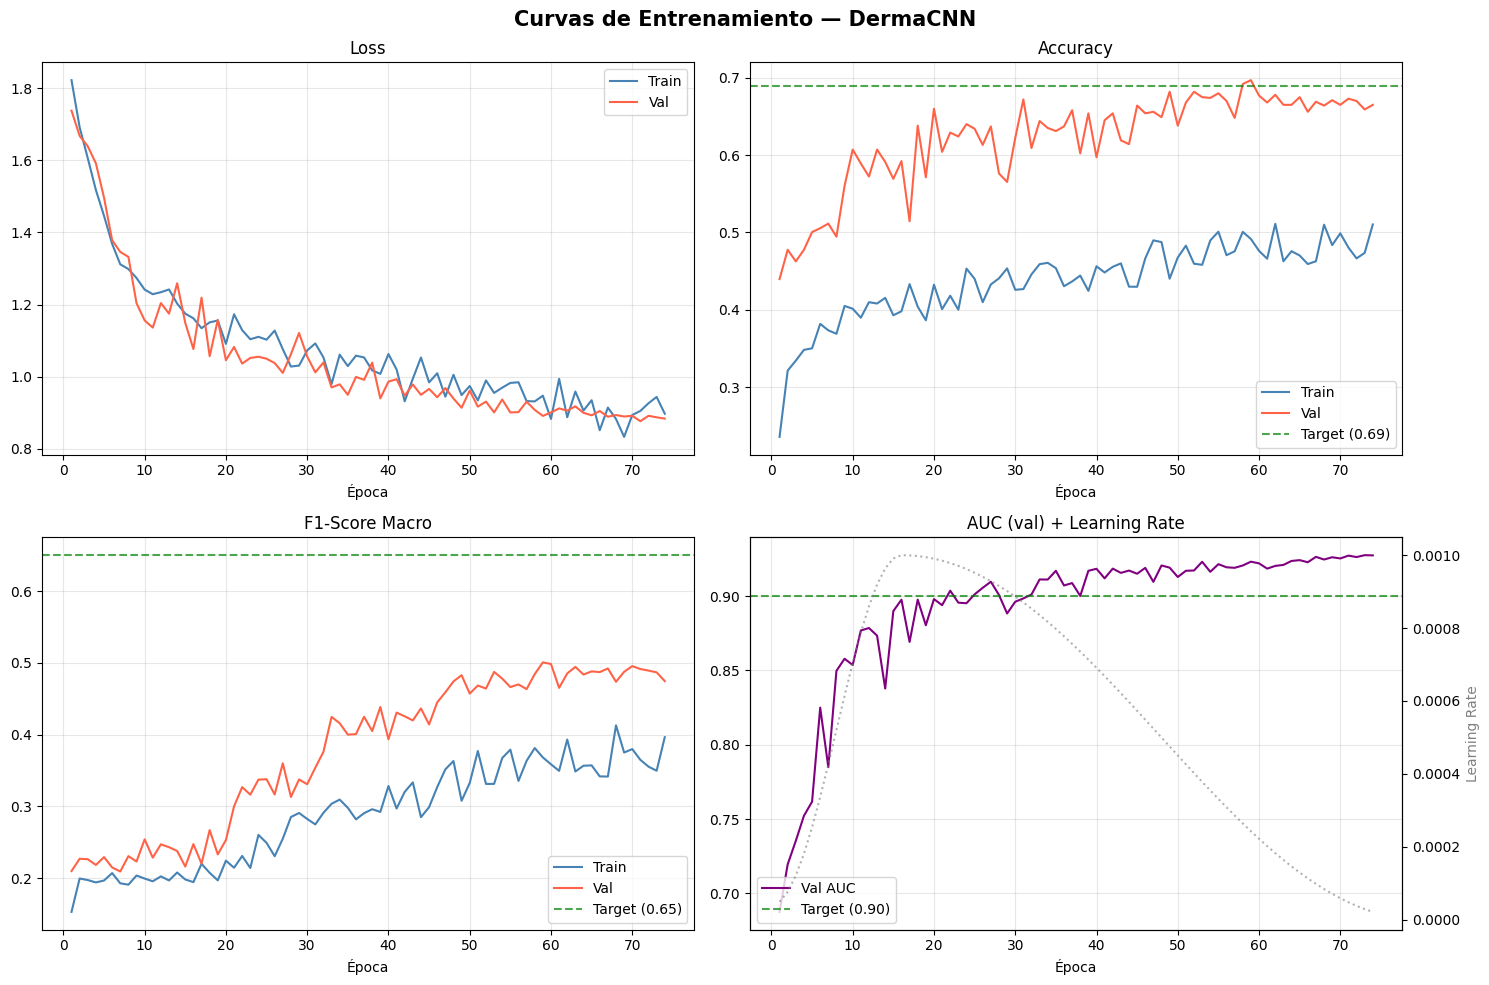

✅ Guardado: curvas_entrenamiento.png


In [5]:
epochs_ran = len(history['train_loss'])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Curvas de Entrenamiento — DermaCNN', fontsize=15, fontweight='bold')

# Loss
ax = axes[0][0]
ax.plot(ep_range, history['train_loss'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_loss'],   label='Val',   color='tomato')
ax.set_title('Loss')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# Accuracy
ax = axes[0][1]
ax.plot(ep_range, history['train_acc'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_acc'],   label='Val',   color='tomato')
ax.axhline(0.69, color='green', linestyle='--', alpha=0.7, label='Target (0.69)')
ax.set_title('Accuracy')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# F1-Macro
ax = axes[1][0]
ax.plot(ep_range, history['train_f1'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_f1'],   label='Val',   color='tomato')
ax.axhline(0.65, color='green', linestyle='--', alpha=0.7, label='Target (0.65)')
ax.set_title('F1-Score Macro')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# AUC + LR
ax = axes[1][1]
ax.plot(ep_range, history['val_auc'], label='Val AUC', color='purple')
ax.axhline(0.90, color='green', linestyle='--', alpha=0.7, label='Target (0.90)')
ax2 = ax.twinx()
ax2.plot(ep_range, history['lr'], color='gray', linestyle=':', alpha=0.6, label='LR')
ax2.set_ylabel('Learning Rate', color='gray')
ax.set_title('AUC (val) + Learning Rate')
ax.set_xlabel('Época')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: curvas_entrenamiento.png')

## 8. Evaluación Final en Test Set

In [9]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load(CONFIG['checkpoint'], map_location=DEVICE))
print(f'Modelo cargado desde: {CONFIG["checkpoint"]}')

# Evaluar en Test Set
test_loss, test_acc, test_f1, test_auc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

print()
print('='*50)
print('  RESULTADOS FINALES — TEST SET')
print('='*50)

TARGETS = {'Accuracy': 0.69, 'AUC': 0.90, 'F1-Macro': 0.65}
results  = {'Accuracy': test_acc, 'AUC': test_auc, 'F1-Macro': test_f1}

for metric, value in results.items():
    target = TARGETS[metric]
    status = 'ok -' if value >= target else 'X'
    print(f'  {status} {metric:<12}: {value:.4f}  (target ≥ {target})')

print('='*50)
all_pass = all(results[m] >= TARGETS[m] for m in TARGETS)
print(f'  {"APROBADO" if all_pass else "AÚN NO CUMPLE"}')
print('='*50)

C:\Users\isape\AppData\Local\Temp\ipykernel_10556\3200187190.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CONFIG['checkpoint'], map_l

Modelo cargado desde: best_model_v6.pth

  RESULTADOS FINALES — TEST SET
  ok - Accuracy    : 0.6993  (target ≥ 0.69)
  ok - AUC         : 0.9229  (target ≥ 0.9)
  X F1-Macro    : 0.5062  (target ≥ 0.65)
  AÚN NO CUMPLE


## 9. Matriz de Confusión

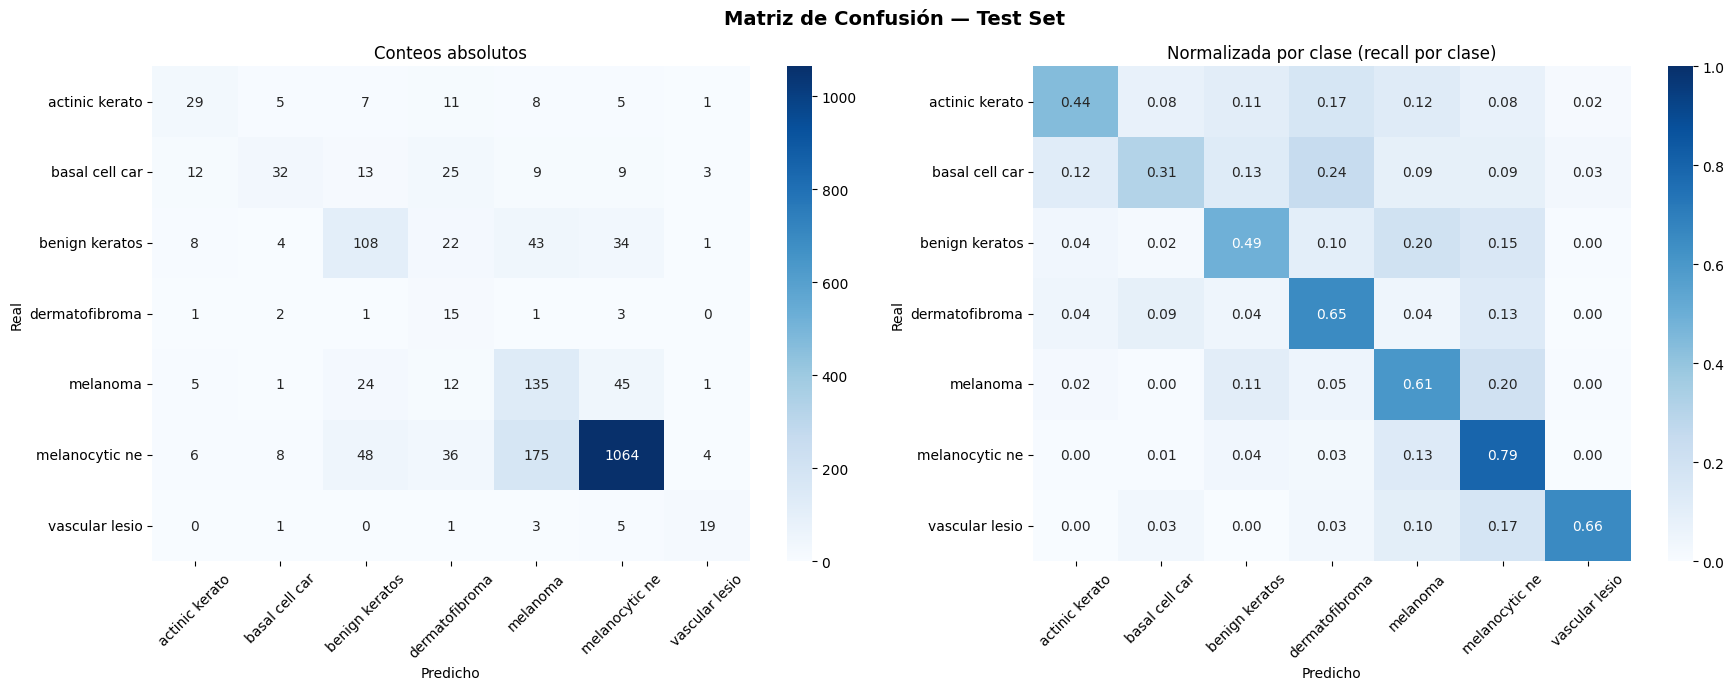

✅ Guardado: confusion_matrix.png

Reporte por clase:
                                                 precision    recall  f1-score   support

actinic keratoses and intraepithelial carcinoma       0.48      0.44      0.46        66
                           basal cell carcinoma       0.60      0.31      0.41       103
                  benign keratosis-like lesions       0.54      0.49      0.51       220
                                 dermatofibroma       0.12      0.65      0.21        23
                                       melanoma       0.36      0.61      0.45       223
                               melanocytic nevi       0.91      0.79      0.85      1341
                               vascular lesions       0.66      0.66      0.66        29

                                       accuracy                           0.70      2005
                                      macro avg       0.52      0.56      0.51      2005
                                   weighted avg       0

In [7]:
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizada por fila

short_names = [n[:14] for n in CLASS_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de Confusión — Test Set', fontsize=14, fontweight='bold')

# Absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=axes[0])
axes[0].set_title('Conteos absolutos')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalizada por clase (recall por clase)')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: confusion_matrix.png')

# Métricas por clase
from sklearn.metrics import classification_report
print('\nReporte por clase:')
print(classification_report(test_labels, test_preds,
      target_names=CLASS_NAMES, zero_division=0))

## 11. Guardar artefactos para Fase 4

In [8]:
import pickle

# Guardar resultados del test para usar en Fase 4 (Grad-CAM)
artefactos = {
    'test_preds' : test_preds,
    'test_labels': test_labels,
    'test_probs' : test_probs,
    'history'    : history,
    'test_acc'   : test_acc,
    'test_f1'    : test_f1,
    'test_auc'   : test_auc,
}

with open('test_results.pkl', 'wb') as f:
    pickle.dump(artefactos, f)

print('Archivos listos para Fase 4:')
print('  best_model.pth    — pesos del mejor modelo')
print('  test_results.pkl  — métricas y predicciones del test set')
print('  curvas_entrenamiento.png — para el reporte IEEE')
print('  confusion_matrix.png    — para el reporte IEEE')
print()
print('✅ Fase 3 completa — listo para Fase 4: Grad-CAM')

Archivos listos para Fase 4:
  best_model.pth    — pesos del mejor modelo
  test_results.pkl  — métricas y predicciones del test set
  curvas_entrenamiento.png — para el reporte IEEE
  confusion_matrix.png    — para el reporte IEEE

✅ Fase 3 completa — listo para Fase 4: Grad-CAM


## ✅ Resumen Fase 3

| Decisión | Justificación |
|----------|---------------|
| `AdamW` | Mejor regularización que Adam estándar (weight decay separado) |
| `CosineAnnealingLR` | Evita mínimos locales — baja LR suavemente |
| `CrossEntropyLoss(weight=...)` | Segunda línea de defensa contra desbalance |
| Gradient clipping (norm=1.0) | Evita explosión de gradientes en las fusiones no lineales |
| Early stopping en F1-Macro | Métrica más representativa para datasets desbalanceados |
| Checkpoint del mejor modelo | Evita sobreajuste al final del entrenamiento |

**Siguiente paso → Fase 4: Evaluación + Grad-CAM (XAI)**